# Training

## 1. Load data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

from analyse.analyse import (evaluer_auc, groupe_region, importance_permutation, tableau_tranches,
                             tracer_importances)
from cible import (NOUVELLES_VARIABLES, TAUX_MAX, TAUX_MIN, VARIABLES_MODELE, ajouter_attributs,
                   ajouter_eloignee, ajuster_modele_decision, appliquer_seuil, choisir_seuil,
                   cible_individuelle, coefficients, entrainer_modele_cible, score_merite)

In [2]:
demandes = pd.read_csv('data/donnees_demandes.csv')
groupe_hist = np.where(ajouter_eloignee(demandes)['eloignee'] == 1, 'Eloignee', 'Centre')
ajouter_attributs(demandes, reference=demandes.copy())
print(f'{len(demandes)} dossiers historiques')

10000 dossiers historiques


In [3]:
demandes.info()
print()
print(demandes.describe(include='all').T[['count', 'unique', 'top', 'mean']])

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   cote_r_rel_a_region                10000 non-null  float64
 1   cote_r_rel_au_revenu               10000 non-null  float64
 2   id_candidat                        10000 non-null  str    
 3   cote_r_equivalent                  10000 non-null  float64
 4   programme_etudes                   10000 non-null  str    
 5   region_administrative              10000 non-null  str    
 6   code_postal_3                      10000 non-null  str    
 7   revenu_familial_estime             10000 non-null  int64  
 8   heures_travail_semaine             10000 non-null  int64  
 9   distance_domicile_campus_km        10000 non-null  float64
 10  premiere_generation_universitaire  10000 non-null  int64  
 11  decision_octroi                    10000 non-null  int64  
dtypes:

In [4]:
# La cible n'est pas decision_octroi, biaisee, mais la cible individuelle (cible.cible_individuelle).
# Elle se construit a partir d'un modele de decision du comite (regression logistique avec la region) :
# - evaluation : modele de decision ajuste sur train seulement (cellule 12), pour eviter toute fuite ;
# - modele final : modele de decision ajuste sur tout l'historique (section Prediction).
# decision_octroi et la region restent donc dans `demandes` : elles servent a construire la cible.
print('Taux d\'octroi du comite par groupe :',
      demandes['decision_octroi'].groupby(groupe_hist).mean().round(3).to_dict())

Taux d'octroi du comite par groupe : {'Centre': 0.484, 'Eloignee': 0.273}


## 2. Prepare features

In [5]:
# Variables du modele : celles de cible.VARIABLES_MODELE (ni la region ni le code postal, ni la distance
# ni le revenu, dont la cible a retire l'effet), plus la cote R relative a la region et au revenu.
VARIABLES = VARIABLES_MODELE + NOUVELLES_VARIABLES
CATEGORIELLES = ['programme_etudes']
print('Variables du modele :', VARIABLES)

Variables du modele : ['cote_r_equivalent', 'heures_travail_semaine', 'premiere_generation_universitaire', 'programme_etudes', 'cote_r_rel_a_region', 'cote_r_rel_au_revenu']


In [6]:
for col in VARIABLES + ['decision_octroi', 'region_administrative']:
    if col not in demandes.columns:
        raise ValueError(f"Colonne {col} manquante dans les données d'entrée.")

In [7]:
# Meme decoupage que la baseline et model_corrige.ipynb (stratifie sur la decision du comite).
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)

In [8]:
def preparer(df):
    """Variables du modele, dans l'ordre attendu par le pipeline."""
    return df[VARIABLES]

In [9]:
# Budget (TAUX_MIN, TAUX_MAX) et choix du seuil (choisir_seuil, appliquer_seuil) : voir cible.py.
# Le seuil est cherche a l'interieur du budget, avec une marge d'un point.

In [10]:
# Modele de decision du comite ajuste sur train seulement.
modele_valid = ajuster_modele_decision(train)

X_train, X_test = preparer(train), preparer(test)
# y_train : cible individuelle souple.
y_train = cible_individuelle(modele_valid, train)

# Reference de merite binaire : score de merite >= seuil optimal, choisi sur train contre la cible souple.
# y_train_binaire sert d'etiquettes a ThresholdOptimizer ; y_test est la reference d'evaluation.
merite_train = score_merite(modele_valid, train, reference=train)
merite_test = score_merite(modele_valid, test, reference=train)
seuil_merite, taux_merite = choisir_seuil(merite_train, y_train)
y_train_binaire = appliquer_seuil(merite_train, seuil_merite)
y_test = appliquer_seuil(merite_test, seuil_merite)

print('Moyenne de y_train par groupe :', pd.Series(y_train).groupby(groupe_hist[train.index]).mean().round(3).to_dict())
print(f'Seuil de merite {seuil_merite:.3f} : {taux_merite:.1%} de meritants sur train, {y_test.mean():.1%} sur test')

Moyenne de y_train par groupe : {'Centre': 0.484, 'Eloignee': 0.447}
Seuil de merite 0.598 : 43.0% de meritants sur train, 44.0% sur test


## 3. Training (fit)

Alternative model

In [11]:
from fairlearn.postprocessing import ThresholdOptimizer

modele = entrainer_modele_cible(train, y_train, new_features=NOUVELLES_VARIABLES)
proba_train = modele.predict_proba(X_train)[:, 1]
proba_test = modele.predict_proba(X_test)[:, 1]

# Seuil du modele seul : choisi sur train (contre la cible souple), applique sur test.
seuil_modele, taux_modele = choisir_seuil(proba_train, y_train)
y_pred = appliquer_seuil(proba_test, seuil_modele)

# Post-traitement : ThresholdOptimizer choisit lui-meme un seuil par groupe pour egaliser la TPR.
# Ajuste sur train, avec les etiquettes de merite binaires (y_train_binaire) et le groupe de chaque
# dossier ; ses decisions sur test sont utilisees telles quelles.
# groupe_train, groupe_test = groupe_hist[train.index], groupe_hist[test.index]

# postprocesseur = ThresholdOptimizer(
#     estimator=modele,
#     constraints="true_positive_rate_parity",
#     objective="balanced_accuracy_score",
#     prefit=True,
#     predict_method="predict_proba",
# )
# postprocesseur.fit(X_train, y_train_binaire, sensitive_features=groupe_train)
# y_pred = postprocesseur.predict(X_test, sensitive_features=groupe_test, random_state=42)

# AUC ponderee contre la cible souple de test (ajustement du modele).
cible_te = cible_individuelle(modele_valid, test, reference=train)
n = len(test)
auc = roc_auc_score(np.r_[np.ones(n), np.zeros(n)], np.r_[proba_test, proba_test],
                    sample_weight=np.r_[cible_te, 1 - cible_te])
print(f'AUC contre la cible individuelle : {auc:.3f}')
print(f'Modele seul           : seuil {seuil_modele:.3f} (train : {taux_modele:.1%} d\'octroi), '
      f'test : {y_pred.mean():.1%} d\'octroi, exactitude {accuracy_score(y_test, y_pred):.2%}')
# print(f'+ ThresholdOptimizer  : test : {y_pred.mean():.1%} d\'octroi, exactitude {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, digits=3))

AUC contre la cible individuelle : 0.947
Modele seul           : seuil 0.580 (train : 43.0% d'octroi), test : 43.8% d'octroi, exactitude 95.87%

              precision    recall  f1-score   support

           0      0.962     0.964     0.963      1681
           1      0.954     0.951     0.953      1319

    accuracy                          0.959      3000
   macro avg      0.958     0.958     0.958      3000
weighted avg      0.959     0.959     0.959      3000



## 4. Evaluation

### metrics

In [12]:
# groupe_region : voir analyse/analyse.py.

In [13]:
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    selection_rate,
    true_positive_rate,
)

groupe_test = groupe_hist[test.index]

cadre = MetricFrame(
    metrics={
        'exactitude': accuracy_score,
        'taux_selection': selection_rate,
        'taux_vrais_positifs': true_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=groupe_test,
)
print(cadre.by_group.round(4))

ecart_parite = demographic_parity_difference(y_test, y_pred, sensitive_features=groupe_test)
print(f'\nEcart de parite demographique : {ecart_parite:.4f}')

                     exactitude  taux_selection  taux_vrais_positifs
sensitive_feature_0                                                 
Centre                   0.9555          0.4445               0.9404
Eloignee                 0.9633          0.4294               0.9688



Ecart de parite demographique : 0.0151


In [14]:
# AUC contre la reference de merite binarisee, globale et par groupe.
print(evaluer_auc(modele, X_test, y_test, groupes=groupe_test).round(4))

global      0.9919
Centre      0.9908
Eloignee    0.9939
Name: auc, dtype: float64


### Confusion matrix

In [15]:
for g in ['Centre', 'Eloignee']:
    masque = groupe_test == g
    matrice = pd.DataFrame(confusion_matrix(y_test[masque], y_pred[masque]),
                           index=['merite 0', 'merite 1'], columns=['predit 0', 'predit 1'])
    print(f'--- {g} ---')
    print(matrice, end='\n\n')

--- Centre ---
          predit 0  predit 1
merite 0       938        31
merite 1        48       758

--- Eloignee ---
          predit 0  predit 1
merite 0       683        29
merite 1        16       497



### Feature importance

num__cote_r_equivalent                     5.296
num__cote_r_rel_au_revenu                 -1.460
num__heures_travail_semaine                0.638
cat__programme_etudes_Arts et lettres     -0.096
num__premiere_generation_universitaire    -0.084
cat__programme_etudes_Sciences sociales   -0.083
num__cote_r_rel_a_region                  -0.068
cat__programme_etudes_Sciences             0.037
cat__programme_etudes_Sante                0.033
cat__programme_etudes_Genie               -0.003
Name: coefficient standardise, dtype: float64



                                   moyenne  ecart_type
cote_r_equivalent                   0.6041      0.0046
cote_r_rel_au_revenu                0.0228      0.0023
heures_travail_semaine              0.0163      0.0010
premiere_generation_universitaire   0.0005      0.0001
cote_r_rel_a_region                 0.0002      0.0001
programme_etudes                    0.0002      0.0000


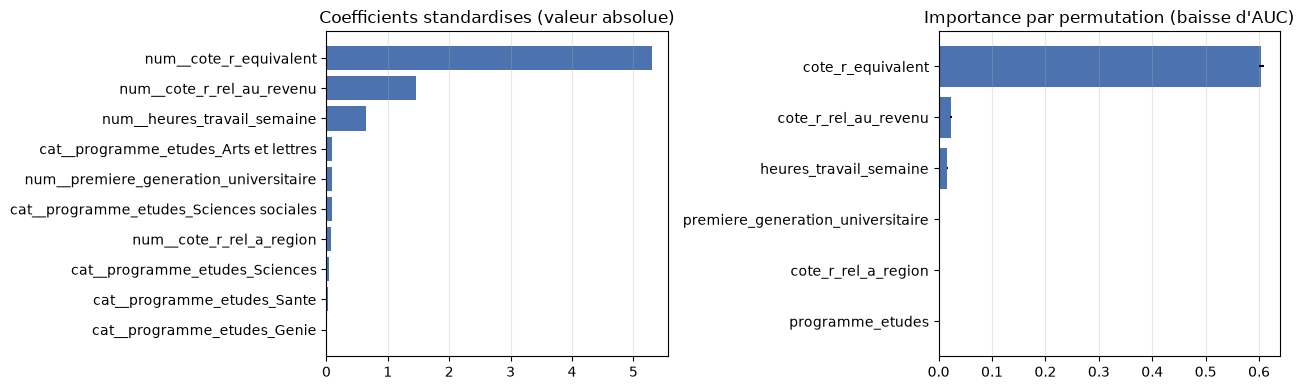

In [16]:
# Regression logistique : coefficients standardises, puis importance par permutation (baisse d'AUC).
coefs = coefficients(modele).rename('coefficient standardise')
print(coefs.round(3))
imp_perm = importance_permutation(modele, X_test, y_test)
print()
print(imp_perm.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tracer_importances(coefs.abs().sort_values(ascending=False), 'Coefficients standardises (valeur absolue)', ax=axes[0])
tracer_importances(imp_perm, 'Importance par permutation (baisse d\'AUC)', ax=axes[1])
plt.tight_layout()
plt.show()

### By slice

In [17]:
# Metriques par tranche contre la reference de merite (voir analyse_slices.ipynb pour le detail).
g_te = pd.Series(groupe_test, index=test.index, name='groupe')
bornes_revenu = np.quantile(train['revenu_familial_estime'], [0.2, 0.4, 0.6, 0.8])   # quintiles de train
tranches = {
    'region': test['region_administrative'].rename('region'),
    'cote R': pd.concat([pd.cut(test['cote_r_equivalent'], [0, 26, 27, 28, 29, 30, 32, 45]).astype(str)
                         .rename('cote R'), g_te], axis=1),
    'revenu': pd.concat([pd.cut(test['revenu_familial_estime'], np.r_[-np.inf, bornes_revenu, np.inf],
                                labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']).astype(str).rename('revenu'), g_te], axis=1),
}
for nom, tranche in tranches.items():
    print(f'--- {nom} ---')
    print(tableau_tranches(y_test, y_pred, tranche, complet=True).round(3), end='\n\n')

--- region ---
                               effectif  meritants  taux_selection    tpr  \
region                                                                      
Bas-Saint-Laurent                 400.0      159.0           0.410  0.969   
Capitale-Nationale                611.0      282.0           0.452  0.936   
Cote-Nord                         364.0      152.0           0.442  0.967   
Gaspesie-Iles-de-la-Madeleine     461.0      202.0           0.436  0.970   
Montreal                         1164.0      524.0           0.441  0.943   

                                 fpr  precision  exactitude  
region                                                       
Bas-Saint-Laurent              0.041      0.939       0.962  
Capitale-Nationale             0.036      0.957       0.951  
Cote-Nord                      0.066      0.913       0.948  
Gaspesie-Iles-de-la-Madeleine  0.019      0.975       0.976  
Montreal                       0.030      0.963       0.958  

--- cote R

                   effectif  meritants  taux_selection    tpr    fpr  \
cote R   groupe                                                        
(0, 26]  Centre       466.0        1.0           0.000  0.000  0.000   
         Eloignee     408.0        1.0           0.000  0.000  0.000   
(26, 27] Centre       211.0        8.0           0.000  0.000  0.000   
         Eloignee     167.0        5.0           0.012  0.200  0.006   
(27, 28] Centre       223.0       28.0           0.045  0.214  0.021   
         Eloignee     143.0       41.0           0.266  0.756  0.069   
(28, 29] Centre       241.0      141.0           0.606  0.887  0.210   
         Eloignee     124.0       86.0           0.831  0.988  0.474   
(29, 30] Centre       199.0      193.0           0.995  0.995  1.000   
         Eloignee     156.0      153.0           1.000  1.000  1.000   
(30, 32] Centre       266.0      266.0           1.000  1.000    NaN   
         Eloignee     163.0      163.0           1.000  1.000   

                 effectif  meritants  taux_selection    tpr    fpr  precision  \
revenu groupe                                                                   
Q1     Centre       171.0       61.0           0.415  1.000  0.091      0.859   
       Eloignee     383.0      145.0           0.423  1.000  0.071      0.895   
Q2     Centre       308.0      129.0           0.451  1.000  0.056      0.928   
       Eloignee     303.0      120.0           0.432  1.000  0.060      0.916   
Q3     Centre       347.0      142.0           0.427  1.000  0.029      0.959   
       Eloignee     218.0       95.0           0.436  1.000  0.000      1.000   
Q4     Centre       450.0      202.0           0.449  0.975  0.020      0.975   
       Eloignee     202.0       92.0           0.431  0.935  0.009      0.989   
Q5     Centre       499.0      272.0           0.459  0.842  0.000      1.000   
       Eloignee     119.0       61.0           0.429  0.836  0.000      1.000   

                 exactitude

## 5. Front de Pareto équité / utilité

Le levier d'équité de notre méthode est **`retrait`** : la fraction de la pénalité régionale du comité retirée
de la cible (`cible.cible_individuelle(..., retrait=r)`). Avec 0, on garde la pénalité, ce qui revient à
apprendre le comité ; avec 1, on obtient la cible retenue ; au-delà, on surcorrige. Pour chaque valeur, le
modèle est réentraîné sur `train` et évalué sur `test`.

**Comparateurs**, tous entraînés sur `decision_octroi` :
- le **RF de production** (baseline) ;
- le RF corrigé par **`ThresholdOptimizer`** (post-traitement, parité de TPR) ;
- le RF réentraîné par **`ExponentiatedGradient`** sous contrainte de parité de TPR, en balayant la borne
  `difference_bound`.

**Budget identique** : chaque méthode accorde la bourse aux 40 % meilleurs scores de `test`. Seules les
priorités changent, et l'exactitude est comparable d'un point à l'autre. Le modèle soumis (seuil choisi dans
le budget, section 3) est ajouté à part.

**Axes** : l'écart d'égalité des chances (TPR Centre - TPR Éloignée ; 0 = égalité) et l'exactitude, contre
trois références : la **cote R seule** (indépendante), le **mérite retenu** (`y_test`, circulaire pour notre
méthode à `retrait = 1`) et **`decision_octroi`** (fidélité au comité).

In [18]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity
from sklearn.ensemble import RandomForestClassifier

from analyse.analyse import encoder_rf, metriques_equite
from cible import octroi_top_k

TAUX_PARETO = 0.40
groupe_train = groupe_hist[train.index]
REFERENCES = {
    'cote R seule': octroi_top_k(test['cote_r_equivalent'], TAUX_PARETO),
    'merite retenu': y_test,
    'decision_octroi': test['decision_octroi'].to_numpy(),
}


def evaluer(decisions):
    """Ecart d'egalite des chances et exactitude contre chaque reference."""
    return {(nom, mesure): valeur
            for nom, y in REFERENCES.items()
            for mesure, valeur in [('ecart', metriques_equite(y, decisions, groupe_test)['ecart_egalite_chances']),
                                   ('exactitude', (decisions == y).mean())]}


# Notre methode : balayage de la fraction de penalite regionale retiree de la cible.
RETRAITS = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
balayage = {}
for r in RETRAITS:
    modele_r = entrainer_modele_cible(train, cible_individuelle(modele_valid, train, retrait=r),
                                      new_features=NOUVELLES_VARIABLES)
    balayage[r] = evaluer(octroi_top_k(modele_r.predict_proba(X_test)[:, 1], TAUX_PARETO))
balayage = pd.DataFrame(balayage).T.rename_axis('retrait')

# Comparateurs : RF de production, encode comme la baseline (sans les attributs du modele corrige).
X_tr_rf, X_te_rf = encoder_rf(train.drop(columns=NOUVELLES_VARIABLES), test.drop(columns=NOUVELLES_VARIABLES))
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(X_tr_rf, train['decision_octroi'])
proba_rf = rf.predict_proba(X_te_rf)[:, 1]

postprocesseur = ThresholdOptimizer(estimator=rf, constraints='true_positive_rate_parity',
                                    predict_method='predict_proba', prefit=True)
postprocesseur.fit(X_tr_rf, train['decision_octroi'], sensitive_features=groupe_train)
# Decisions randomisees : on classe leur probabilite d'octroi (ex aequo departages par le score du RF).
proba_to = postprocesseur._pmf_predict(X_te_rf, sensitive_features=groupe_test)[:, 1] + 1e-9 * proba_rf

comparateurs = pd.DataFrame({
    'RF de production': evaluer(octroi_top_k(proba_rf, TAUX_PARETO)),
    'RF + ThresholdOptimizer': evaluer(octroi_top_k(proba_to, TAUX_PARETO)),
    'modele soumis (seuil de la section 3)': evaluer(y_pred),
}).T

# ExponentiatedGradient : reentraine le RF sous contrainte (foret de 100 arbres, environ 20 s par borne).
BORNES_EG = [0.2, 0.1, 0.05, 0.02, 0.01]
balayage_eg = {}
for borne in BORNES_EG:
    eg = ExponentiatedGradient(
        RandomForestClassifier(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1),
        constraints=TruePositiveRateParity(difference_bound=borne), eps=0.01, max_iter=50)
    eg.fit(X_tr_rf.astype(float), train['decision_octroi'], sensitive_features=groupe_train)
    balayage_eg[borne] = evaluer(octroi_top_k(eg._pmf_predict(X_te_rf.astype(float))[:, 1], TAUX_PARETO))
balayage_eg = pd.DataFrame(balayage_eg).T.rename_axis('difference_bound')

pd.set_option('display.width', 200)
print('Notre methode (balayage de retrait)')
print(balayage.round(3), end='\n\n')
print('RF + ExponentiatedGradient (balayage de la borne)')
print(balayage_eg.round(3), end='\n\n')
print(comparateurs.round(3))

Notre methode (balayage de retrait)
        cote R seule            merite retenu            decision_octroi           
               ecart exactitude         ecart exactitude           ecart exactitude
retrait                                                                            
0.00           0.171      0.945         0.242      0.920           0.029      0.872
0.25           0.122      0.951         0.189      0.930          -0.008      0.872
0.50           0.057      0.956         0.114      0.943          -0.064      0.869
0.75          -0.001      0.954         0.038      0.950          -0.121      0.864
1.00          -0.058      0.951        -0.033      0.945          -0.162      0.855
1.25          -0.101      0.936        -0.108      0.940          -0.191      0.843
1.50          -0.147      0.920        -0.161      0.929          -0.226      0.827

RF + ExponentiatedGradient (balayage de la borne)
                 cote R seule            merite retenu            decisio

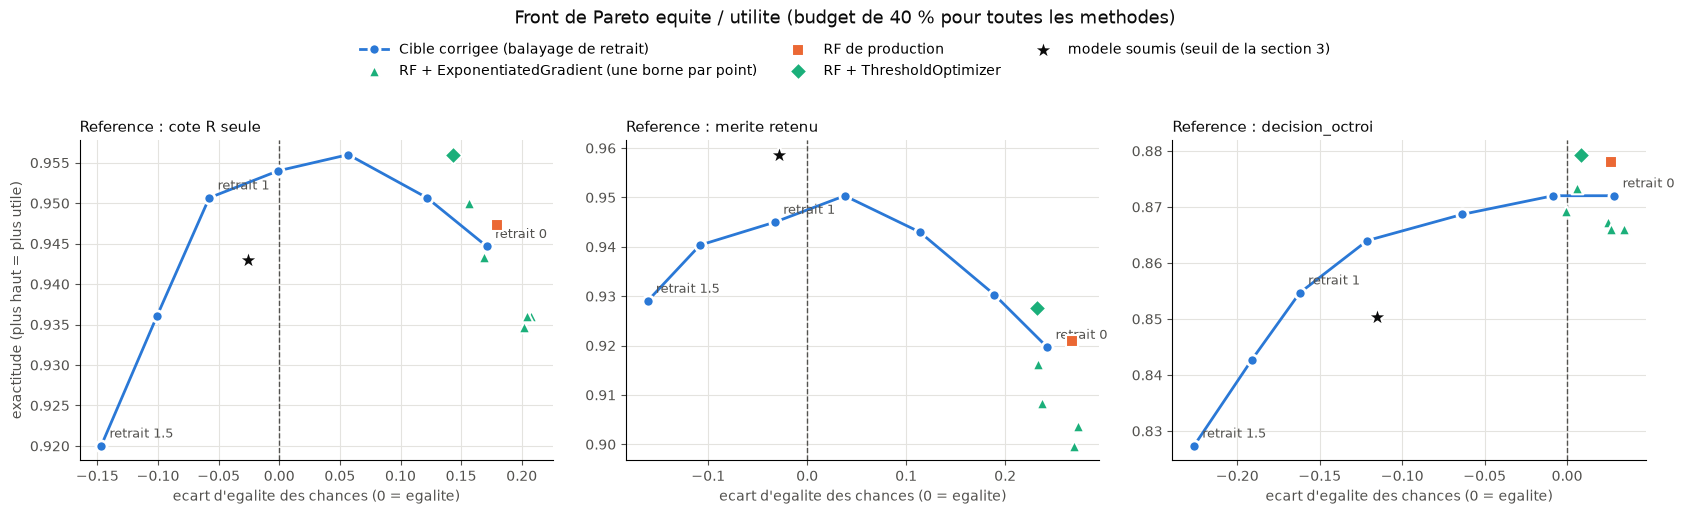

In [19]:
BLEU, ORANGE, VERT, ENCRE, ENCRE_SECONDAIRE, GRILLE = '#2a78d6', '#eb6834', '#1baf7a', '#0b0b0b', '#52514e', '#e4e3df'

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, nom in zip(axes, REFERENCES):
    x, y = balayage[(nom, 'ecart')], balayage[(nom, 'exactitude')]
    ax.axvline(0, color=ENCRE_SECONDAIRE, lw=1, ls='--', zorder=1)
    ax.plot(x, y, '-o', color=BLEU, lw=2, ms=8, mec='white', mew=2, zorder=3,
            label='Cible corrigee (balayage de retrait)')
    for r in [0, 1.0, 1.5]:
        ax.annotate(f'retrait {r:g}', (x[r], y[r]), xytext=(6, 6), textcoords='offset points',
                    fontsize=9, color=ENCRE_SECONDAIRE)
    ax.scatter(balayage_eg[(nom, 'ecart')], balayage_eg[(nom, 'exactitude')], s=70, marker='^', color=VERT,
               edgecolor='white', linewidth=1.5, zorder=4, label='RF + ExponentiatedGradient (une borne par point)')
    for methode, couleur, forme, taille in [('RF de production', ORANGE, 's', 80),
                                            ('RF + ThresholdOptimizer', VERT, 'D', 80),
                                            ('modele soumis (seuil de la section 3)', ENCRE, '*', 220)]:
        ax.scatter(comparateurs.loc[methode, (nom, 'ecart')], comparateurs.loc[methode, (nom, 'exactitude')],
                   s=taille, marker=forme, color=couleur, edgecolor='white', linewidth=1.5, zorder=5, label=methode)
    ax.set_title(f'Reference : {nom}', color=ENCRE, fontsize=11, loc='left')
    ax.set_xlabel('ecart d\'egalite des chances (0 = egalite)', color=ENCRE_SECONDAIRE)
    ax.grid(color=GRILLE, lw=0.8)
    ax.set_axisbelow(True)
    for cote in ['top', 'right']:
        ax.spines[cote].set_visible(False)
    ax.tick_params(colors=ENCRE_SECONDAIRE)
axes[0].set_ylabel('exactitude (plus haut = plus utile)', color=ENCRE_SECONDAIRE)
poignees, etiquettes = axes[0].get_legend_handles_labels()
fig.suptitle('Front de Pareto equite / utilite (budget de 40 % pour toutes les methodes)', fontsize=13, color=ENCRE)
fig.legend(poignees, etiquettes, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

**Lecture.** Le point idéal est sur la ligne pointillée (écart nul), le plus haut possible.
- **Contre la cote R seule (référence indépendante)**, retirer la pénalité améliore **à la fois** l'équité et
  l'exactitude jusqu'à `retrait` = 0.5 à 0.75 : à 0.75, l'écart est nul (-0.001) et l'exactitude passe de
  0.945 à 0.954. Au-delà de 1, on surcorrige : l'écart devient négatif (en faveur des régions éloignées) et
  l'exactitude baisse. Il n'y a donc pas de compromis entre équité et utilité tant qu'on retire un biais :
  le compromis n'apparaît qu'en cas de surcorrection.
- **Contre le mérite retenu**, même forme : le sommet est à 0.75 (écart 0.04, exactitude 0.950), et
  `retrait` = 1 donne -0.03. Ce panneau est en partie circulaire, puisque la référence dérive du même modèle
  de décision.
- **Contre `decision_octroi`**, on retrouve le compromis « classique » : l'exactitude baisse de 0.872 à 0.855
  quand on retire la pénalité. Mais ce panneau ne mesure que la fidélité au comité, biais compris.
- **Les méthodes fairlearn** tiennent leur contrainte contre `decision_octroi` (0.008 pour ThresholdOptimizer,
  -0.001 à 0.035 pour ExponentiatedGradient). Contre les références de mérite, leur écart reste de 0.14 à
  0.27, à peine moins que le RF de production (0.18 et 0.27). Resserrer la borne d'ExponentiatedGradient de
  0.2 à 0.01 ne change presque rien, de façon non monotone : elles égalisent la fidélité à un comité biaisé.
  C'est l'argument central pour corriger la **cible** plutôt que contraindre le modèle.
- **Le modèle soumis** (étoile) accorde environ 44 % des bourses, et non 40 % : il n'est pas directement
  comparable à la courbe. Avec ce budget plus large, son écart est de -0.03 contre les deux références de
  mérite, pour une exactitude de 0.94 à 0.96.

**Niveau de retrait.** À budget de 40 %, l'optimum est vers `retrait` = 0.75 (écart presque nul contre la
cote R seule, meilleure exactitude). La soumission garde `retrait` = 1, qui correspond à l'hypothèse
explicite « traiter chaque candidat comme un candidat du Centre » et laisse une légère surcorrection (-0.03
avec le seuil de la section 3). Un retrait d'environ 0.75 est l'alternative à considérer.

## 6. Surveillance du biais (voir `plan_surveillance.md`)

Quatre indicateurs calculables **sans étiquette** à chaque cohorte de production. L'égalité des chances est
mesurée contre la cote R seule (top 40 %), observée dans chaque dossier. Les valeurs sur `test` servent de
**référence au déploiement**.

In [20]:
from analyse.analyse import comparer_jeux, metriques_equite
from cible import octroi_top_k

VARIABLES_SURVEILLEES = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
                         'distance_domicile_campus_km']
SEUILS = {'taux d\'octroi': (0.36, 0.44), 'ecart de parite': 0.05,
          'ecart d\'egalite des chances (cote R)': 0.05, 'derive KS max': 0.10}


def indicateurs(df, decisions, groupes, historique):
    """Indicateurs de surveillance d'une cohorte, avec seuil et statut (ok / alerte)."""
    m = metriques_equite(octroi_top_k(df['cote_r_equivalent'], 0.40), decisions, groupes)
    ks = comparer_jeux(historique, df, VARIABLES_SURVEILLEES)['ks_statistique']
    valeurs = {'taux d\'octroi': np.mean(decisions), 'ecart de parite': m['ecart_parite'],
               'ecart d\'egalite des chances (cote R)': m['ecart_egalite_chances'], 'derive KS max': ks.max()}
    lignes = {}
    for nom, v in valeurs.items():
        seuil = SEUILS[nom]
        ok = seuil[0] <= v <= seuil[1] if isinstance(seuil, tuple) else abs(v) <= seuil
        lignes[nom] = {'valeur': round(v, 3), 'seuil': seuil, 'statut': 'ok' if ok else 'ALERTE'}
    return pd.DataFrame(lignes).T


reference_deploiement = indicateurs(test, y_pred, groupe_test, historique=train)
print('Valeurs de reference (test)')
print(reference_deploiement)

Valeurs de reference (test)
                                     valeur         seuil statut
taux d'octroi                         0.438  (0.36, 0.44)     ok
ecart de parite                       0.015          0.05     ok
ecart d'egalite des chances (cote R) -0.026          0.05     ok
derive KS max                         0.027           0.1     ok


# Prediction

In [21]:
candidats = pd.read_csv('data/candidats_evaluation.csv')
groupe_cand = np.where(ajouter_eloignee(candidats)['eloignee'] == 1, 'Eloignee', 'Centre')
ajouter_attributs(candidats, reference=demandes)

# Modele final : modele de decision et cible sur tout l'historique, puis modele entraine sur cette cible.
modele_decision = ajuster_modele_decision(demandes)
modele_final = entrainer_modele_cible(demandes, cible_individuelle(modele_decision, demandes),
                                      new_features=NOUVELLES_VARIABLES)
X_cand = preparer(candidats)

In [22]:
# Meme seuil que le modele seul a l'entrainement (choisi sur train), ajuste dans le budget si besoin.
proba_cand = modele_final.predict_proba(X_cand)[:, 1]

# Verification du taux avant d'ecrire : si le seuil sort du budget, on le deplace pour obtenir
# exactement la borne depassee (TAUX_MAX si trop d'octrois, TAUX_MIN si trop peu).
seuil = seuil_modele
taux = np.count_nonzero(proba_cand >= seuil) / len(proba_cand)
if not TAUX_MIN <= taux <= TAUX_MAX:
    borne = TAUX_MAX if taux > TAUX_MAX else TAUX_MIN
    nb_octrois = int(np.floor(borne * len(proba_cand)))
    seuil = np.sort(proba_cand)[::-1][nb_octrois - 1]   # plus petite probabilite encore accordee
    print(f'Taux de {taux:.1%} hors budget avec le seuil {seuil_modele:.3f} : seuil ajuste a {seuil:.3f} '
          f'pour {borne:.0%} d\'octroi')

predictions = appliquer_seuil(proba_cand, seuil)
# groupe_cand = np.where(ajouter_eloignee(candidats)['eloignee'] == 1, 'Eloignee', 'Centre')

soumission = pd.DataFrame({
    'id_candidat': candidats['id_candidat'],
    'decision_octroi': predictions.astype(int),
})
assert len(soumission) == 4000 and soumission['id_candidat'].is_unique
assert set(soumission['decision_octroi']) <= {0, 1}
taux = soumission['decision_octroi'].mean()
assert 0.36 <= taux <= 0.44, f'Hors budget : {taux:.1%}'
# assert TAUX_MIN <= taux <= TAUX_MAX

soumission.to_csv('predictions.csv', index=False)
print(f'{len(soumission)} lignes ecrites dans predictions.csv, taux d\'octroi {taux:.1%}')
print(soumission.groupby(groupe_cand)['decision_octroi'].mean().round(3).to_dict())

Taux de 44.2% hors budget avec le seuil 0.580 : seuil ajuste a 0.583 pour 44% d'octroi
4000 lignes ecrites dans predictions.csv, taux d'octroi 44.0%
{'Centre': 0.449, 'Eloignee': 0.427}


In [23]:
# Surveillance : les 4 000 candidats sont la premiere cohorte de production (historique = 10 000 dossiers).
cohorte = indicateurs(candidats, predictions, groupe_cand, historique=demandes)
print(pd.concat({'reference (test)': reference_deploiement['valeur'], 'cohorte (candidats)': cohorte['valeur'],
                 'seuil': cohorte['seuil'], 'statut': cohorte['statut']}, axis=1))

                                     reference (test) cohorte (candidats)         seuil statut
taux d'octroi                                   0.438                0.44  (0.36, 0.44)     ok
ecart de parite                                 0.015               0.022          0.05     ok
ecart d'egalite des chances (cote R)           -0.026              -0.026          0.05     ok
derive KS max                                   0.027               0.017           0.1     ok
